# CAB420 Assignment 1A Question 1: Regression
Simon Denman (s.denman@qut.edu.au)

## Overview

This notebook provides a brief template for CAB420 Assignment 1A, Question 1. It implements the data loading, and splitting the data into the predictors and response. You are to use the data splits defined here in your response.

The template also provides other suggestions around how to approach the problem.

Please make sure you read the assignment brief on canvas, and check the FAQ for other information.

**Note: File paths used in this template may need to change for your local machine. Please set these based on your local file system structure.**

In [19]:
%pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: C:\Users\olive\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np

In [4]:
# load data
train = pd.read_csv('./data/Q1/communities_train.csv')
val = pd.read_csv('./data/Q1/communities_val.csv')
test = pd.read_csv('./data/Q1/communities_test.csv')

# Pull out X and y components of the data
# if you want to convert this data to numpy format, you can add .to_numpy() to the end of each row below
X_train = train.iloc[:,0:-1]
y_train = train.iloc[:,-1]
X_val = val.iloc[:,0:-1]
y_val = val.iloc[:,-1]
X_test = test.iloc[:,0:-1]
y_test = test.iloc[:,-1]

## Exploratory Data Analysis

The Exploratory Data Analysis informs the methodology, pre-processing and the final regression implementation

### Available Data

Exploring the available data will inform the later EDA

In [5]:
# See dataset shapes
display(
    pd.DataFrame(
        {
            "Dataset" : ["Train", "Validation", "Test"],
            "Total Shape": [train.shape, val.shape, test.shape],
            "X Shape": [X_train.shape, X_val.shape, X_test.shape],
            "y Shape": [y_train.shape, y_val.shape, y_test.shape]
        }
    )
)

,Dataset,Total Shape,X Shape,y Shape
0,Train,"(298, 101)","(298, 100)","(298,)"
1,Validation,"(298, 101)","(298, 100)","(298,)"
2,Test,"(299, 101)","(299, 100)","(299,)"


In [6]:
# Check columnn data types
display(
    pd.DataFrame(
        {
            "Dataset" : ["Train", "Validation", "Test"],
            "Total types": [train.dtypes.value_counts(), val.dtypes.value_counts(), test.dtypes.value_counts()],
            "X types": [X_train.dtypes.value_counts(), X_val.dtypes.value_counts(), X_test.dtypes.value_counts()],
            "y types": [y_train.dtype, y_val.dtype, y_test.dtype]
        }
    )
)

,Dataset,Total types,X types,y types
0,Train,"float64 101 Name: count, dtype: int64","float64 100 Name: count, dtype: int64",float64
1,Validation,"float64 101 Name: count, dtype: int64","float64 100 Name: count, dtype: int64",float64
2,Test,"float64 101 Name: count, dtype: int64","float64 100 Name: count, dtype: int64",float64


#### Interpreting Available Data

From the above cells it can be seen that all the data is already split into train, validation and test sets. Where every datapoint contains 100 floating point predictor variables and the target contains a single floating point output.

Referring to `./data/Q1/Communities_Info.txt`:

> *"[...] Many variables are included so that algorithms that select or learn weights for attributes could be tested. However, clearly unrelated attributes were not included; [...]"*

And the slack response by Simon: 

> *"The "just use as is" refers to not adding/removing terms. [...]"*

Removing / adding variables to the is therefore removed from the scope of this task.

Therefore, the template provides a very strong foundation for the task

### Check for data validity

Searching for NaN, null, inf or -inf values will inform later EDA and the later implementation

In [7]:
display(
    pd.DataFrame(
        {
            "Dataset" : ["Train", "Validation", "Test"],
            "Total null": [train.isnull().sum().sum(), val.isnull().sum().sum(), test.isnull().sum().sum()],
            "Total inf": [np.isinf(train).sum().sum(), np.isinf(val).sum().sum(), np.isinf(test).sum().sum()]
        }
    )
)

,Dataset,Total null,Total inf
0,Train,0,0
1,Validation,0,0
2,Test,0,0


#### Interpreting the validity of the data

As there are no invalid values in any of the data this removes the need to handle invalid data in the task.

### Data distributions

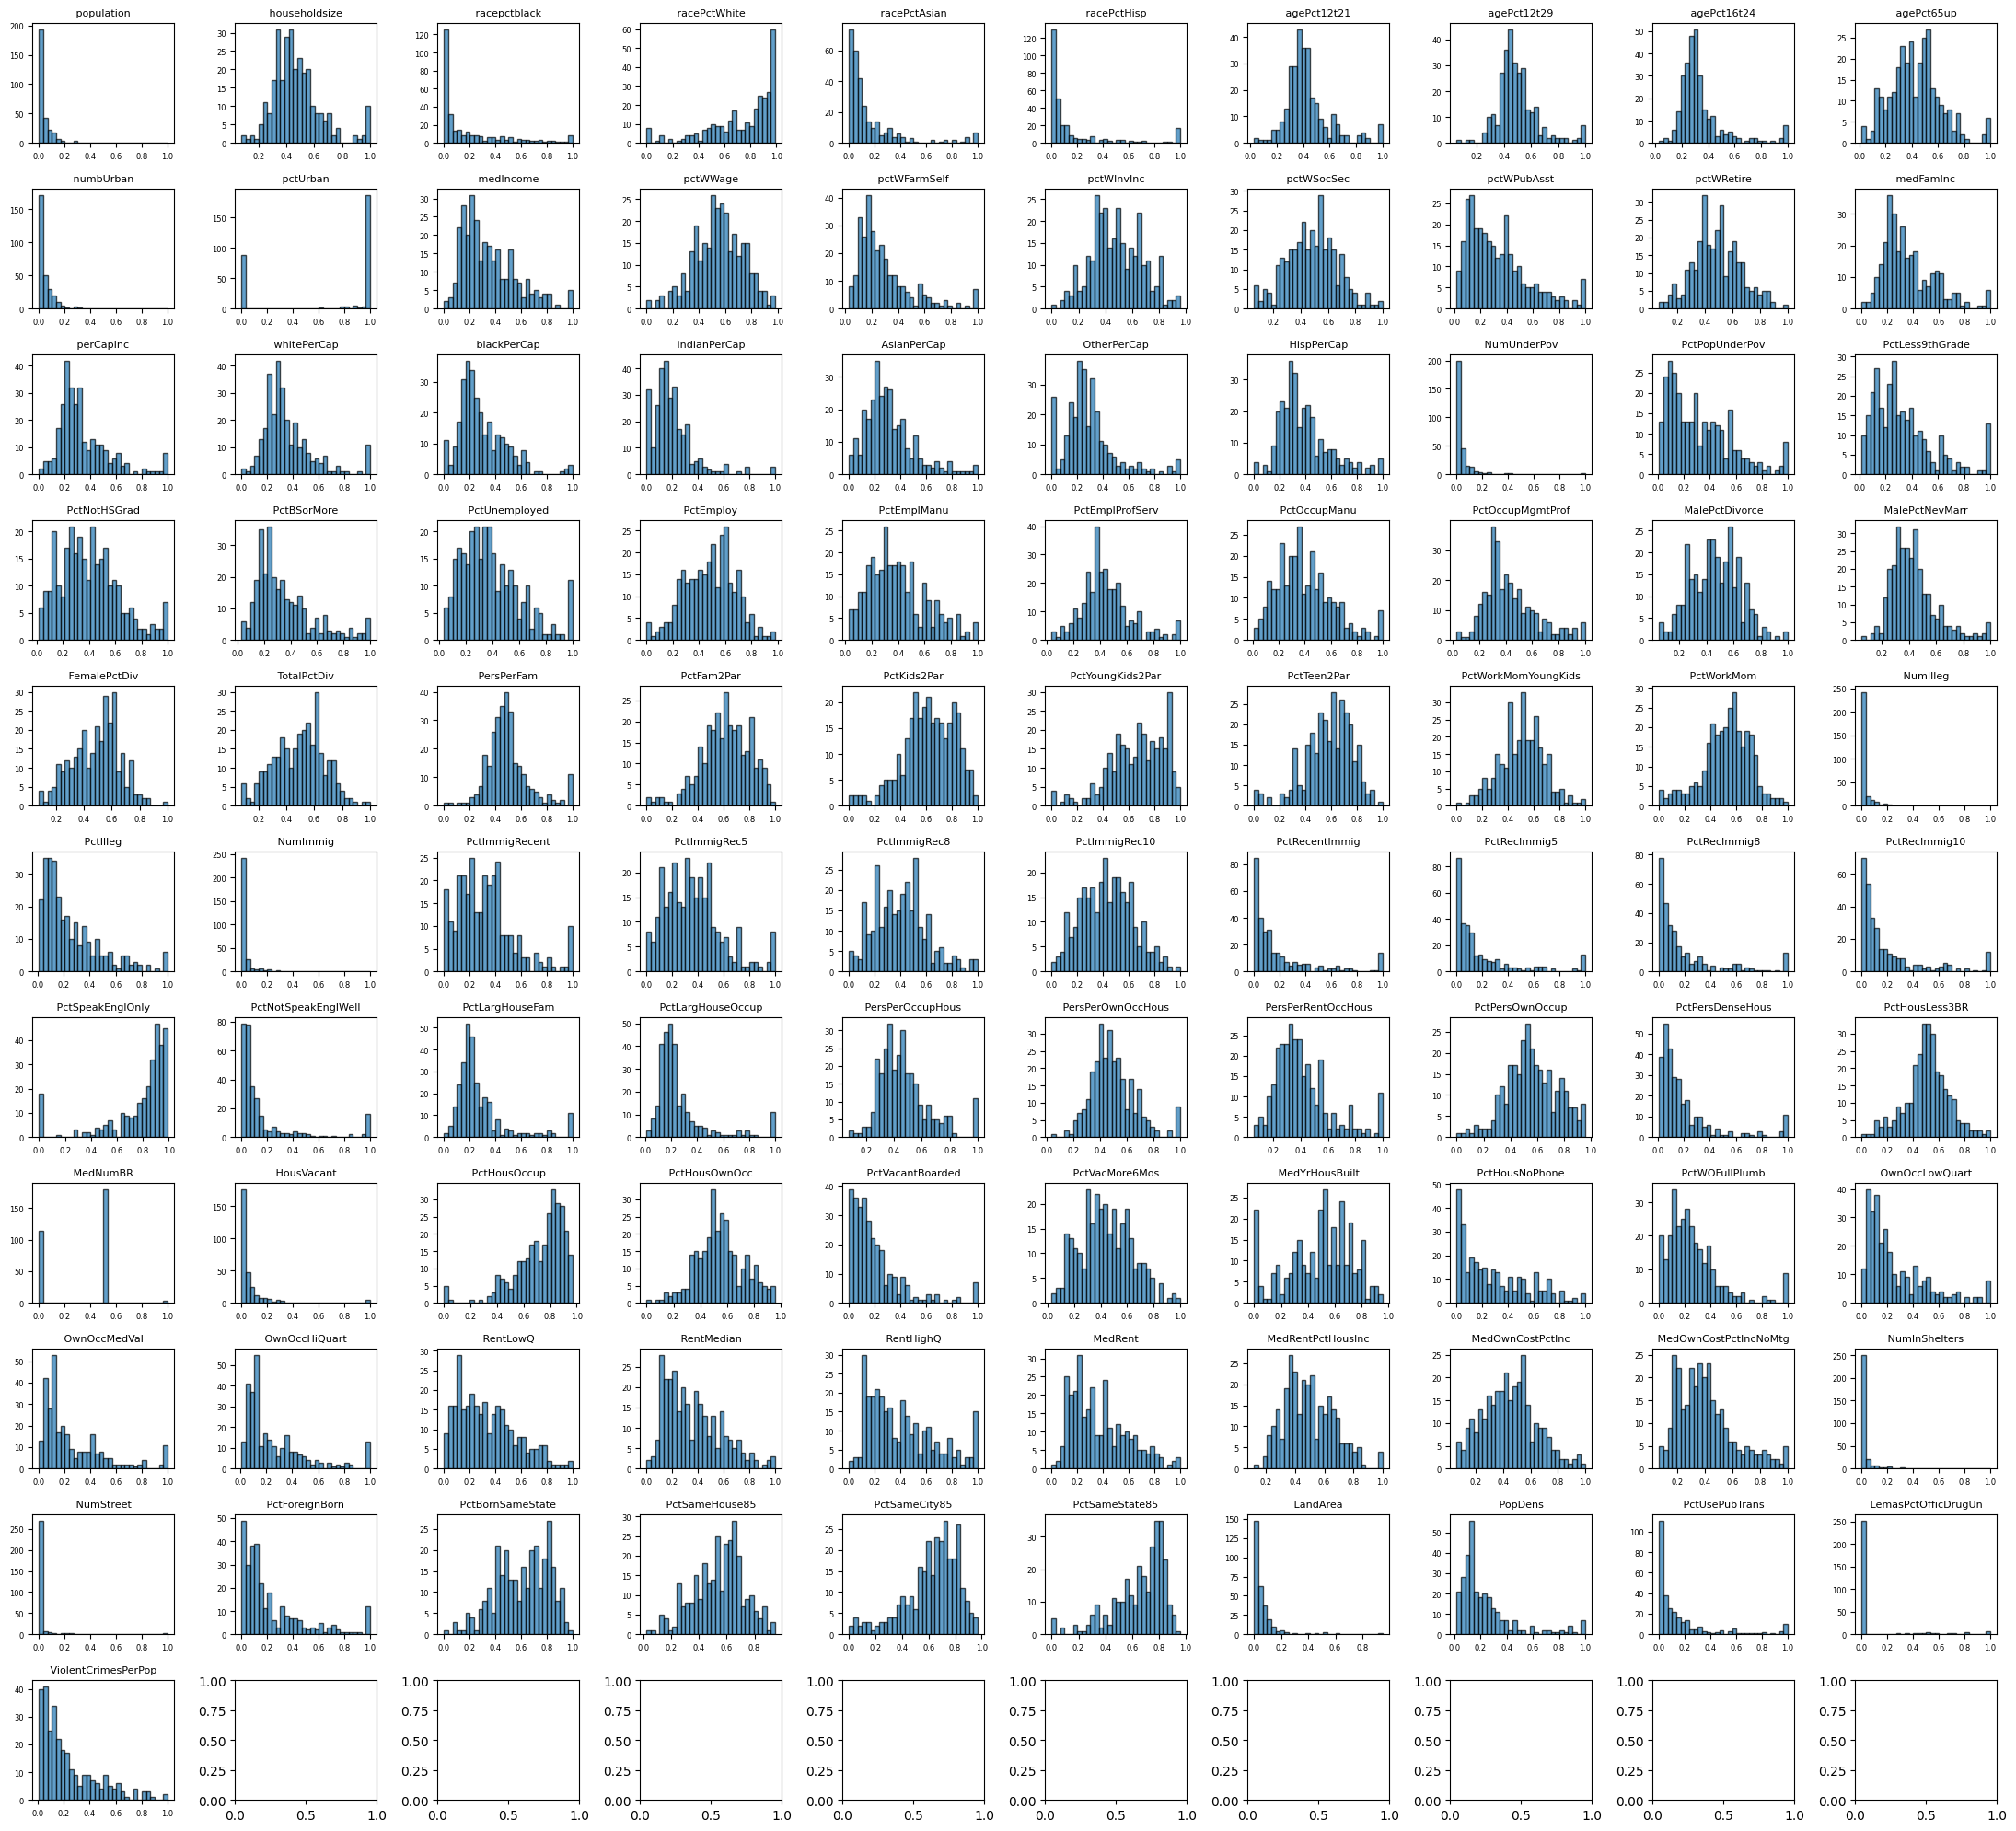

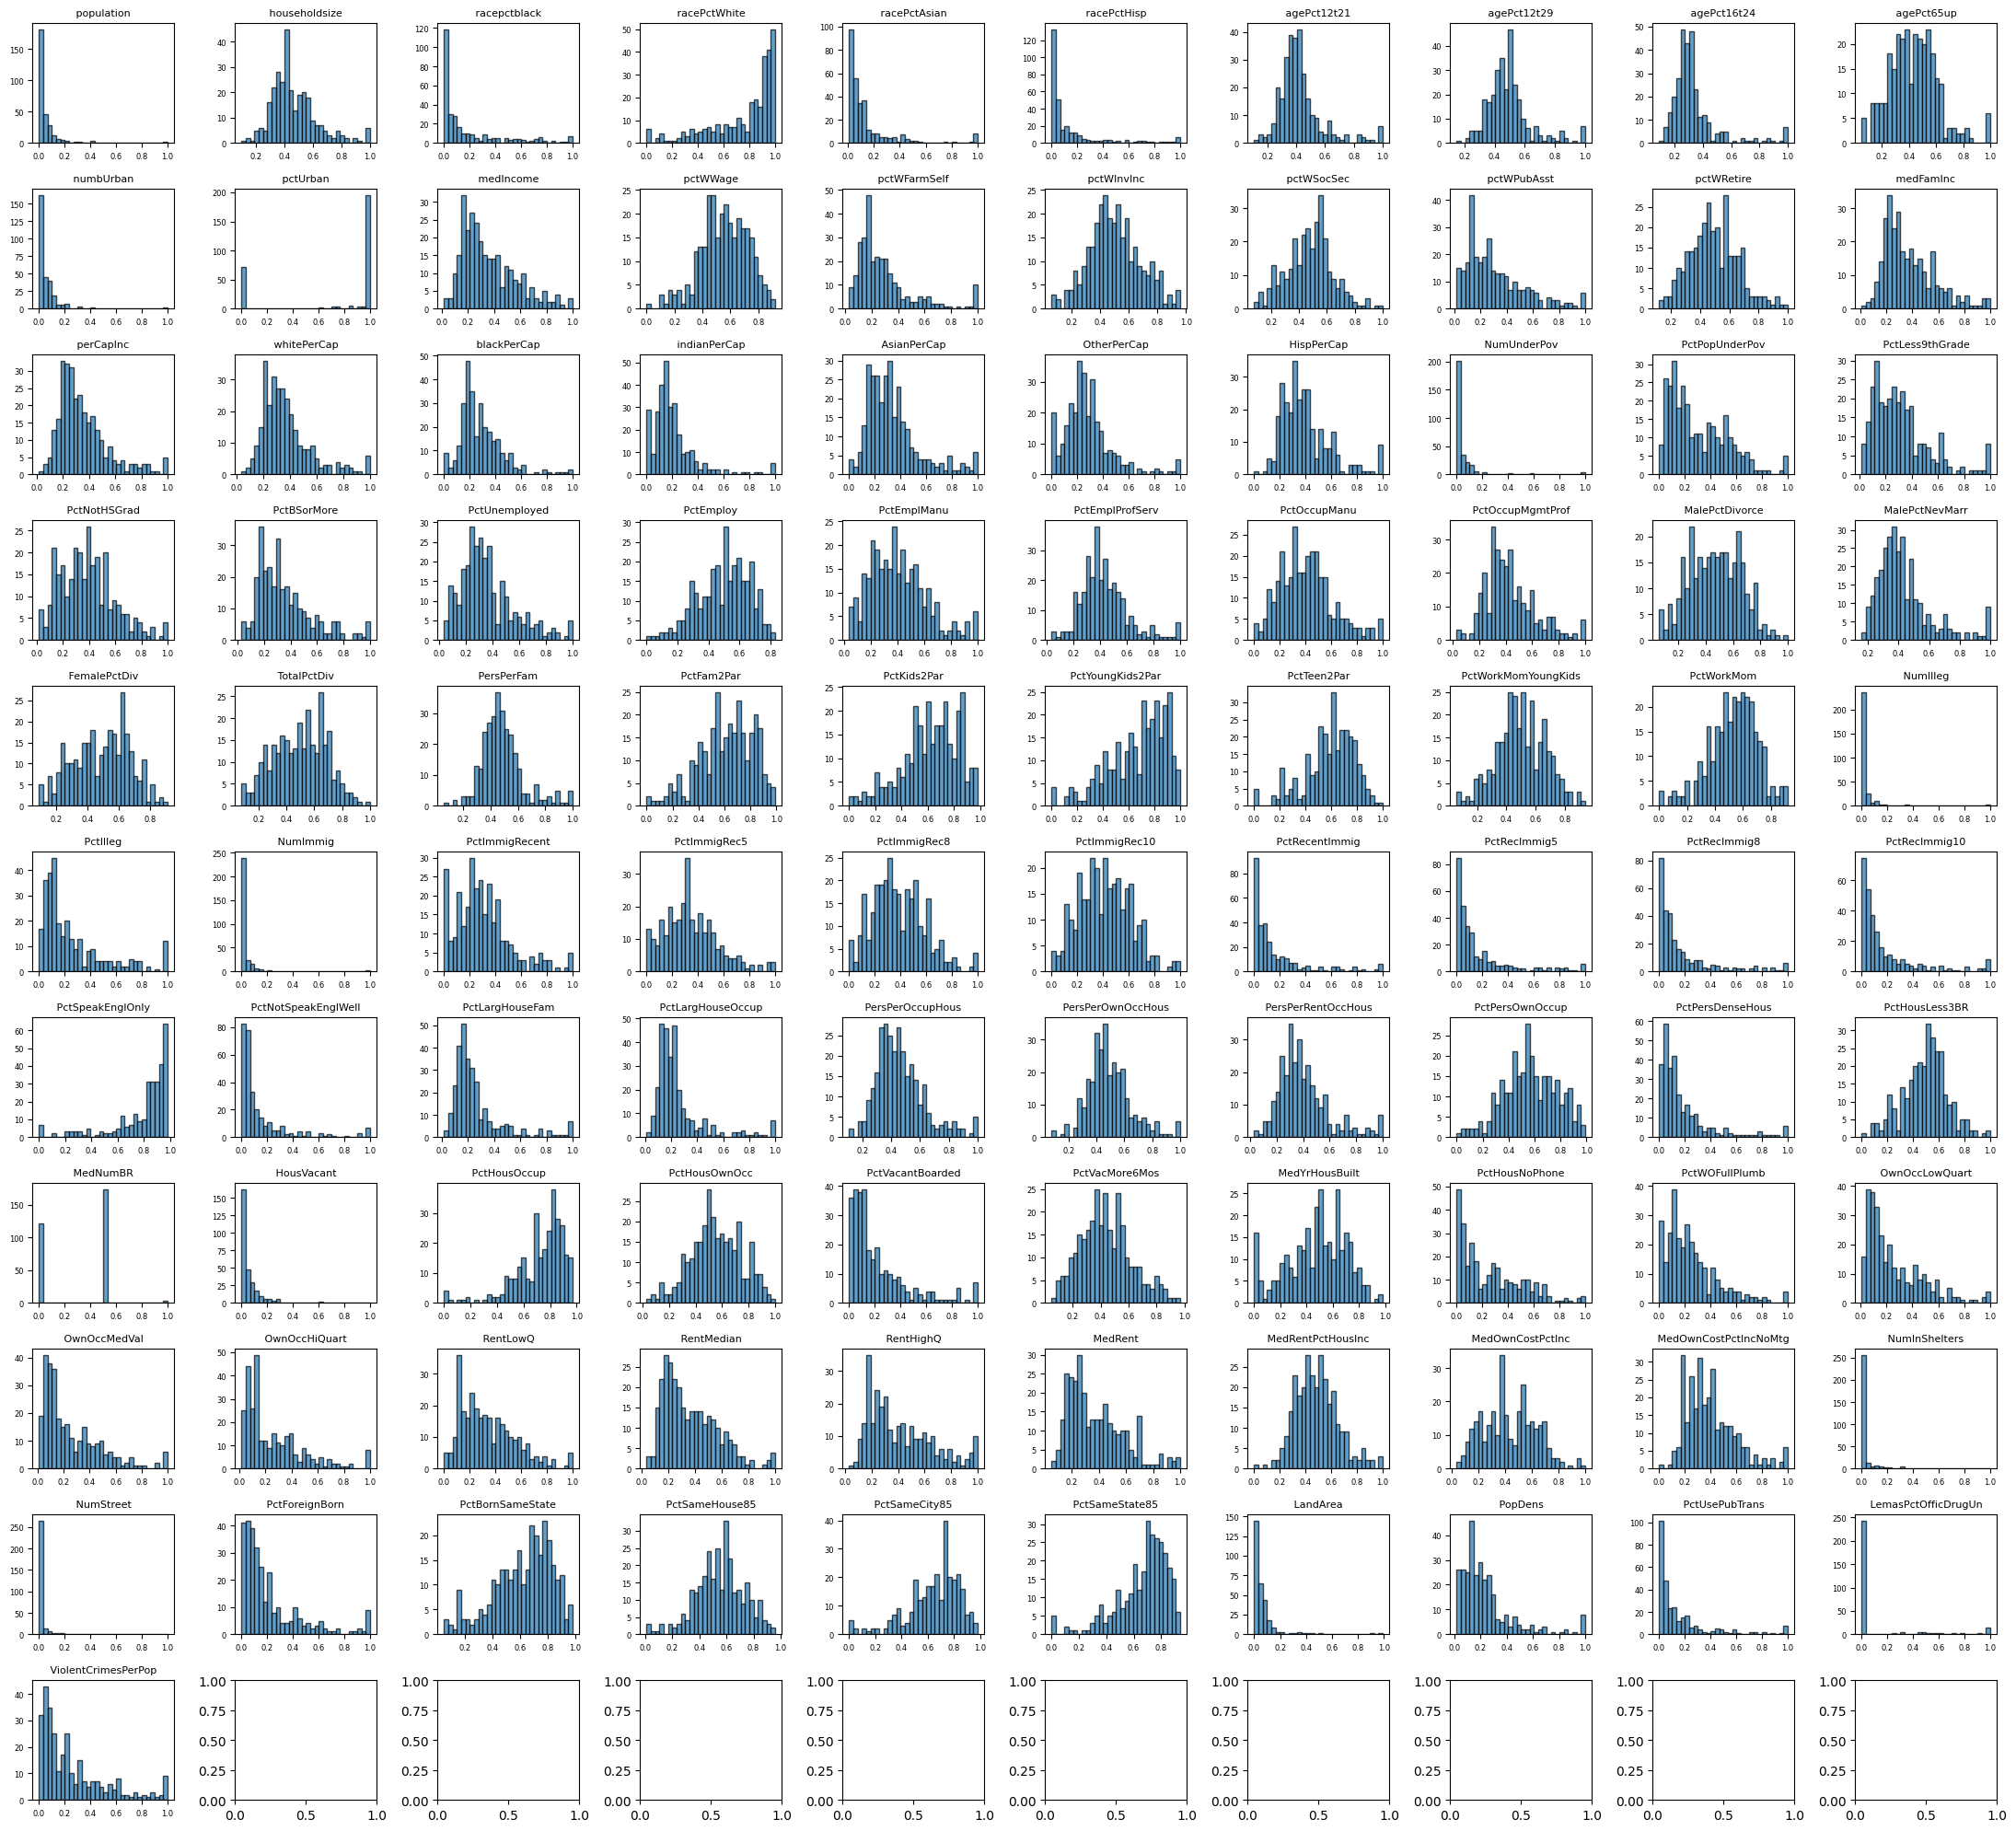

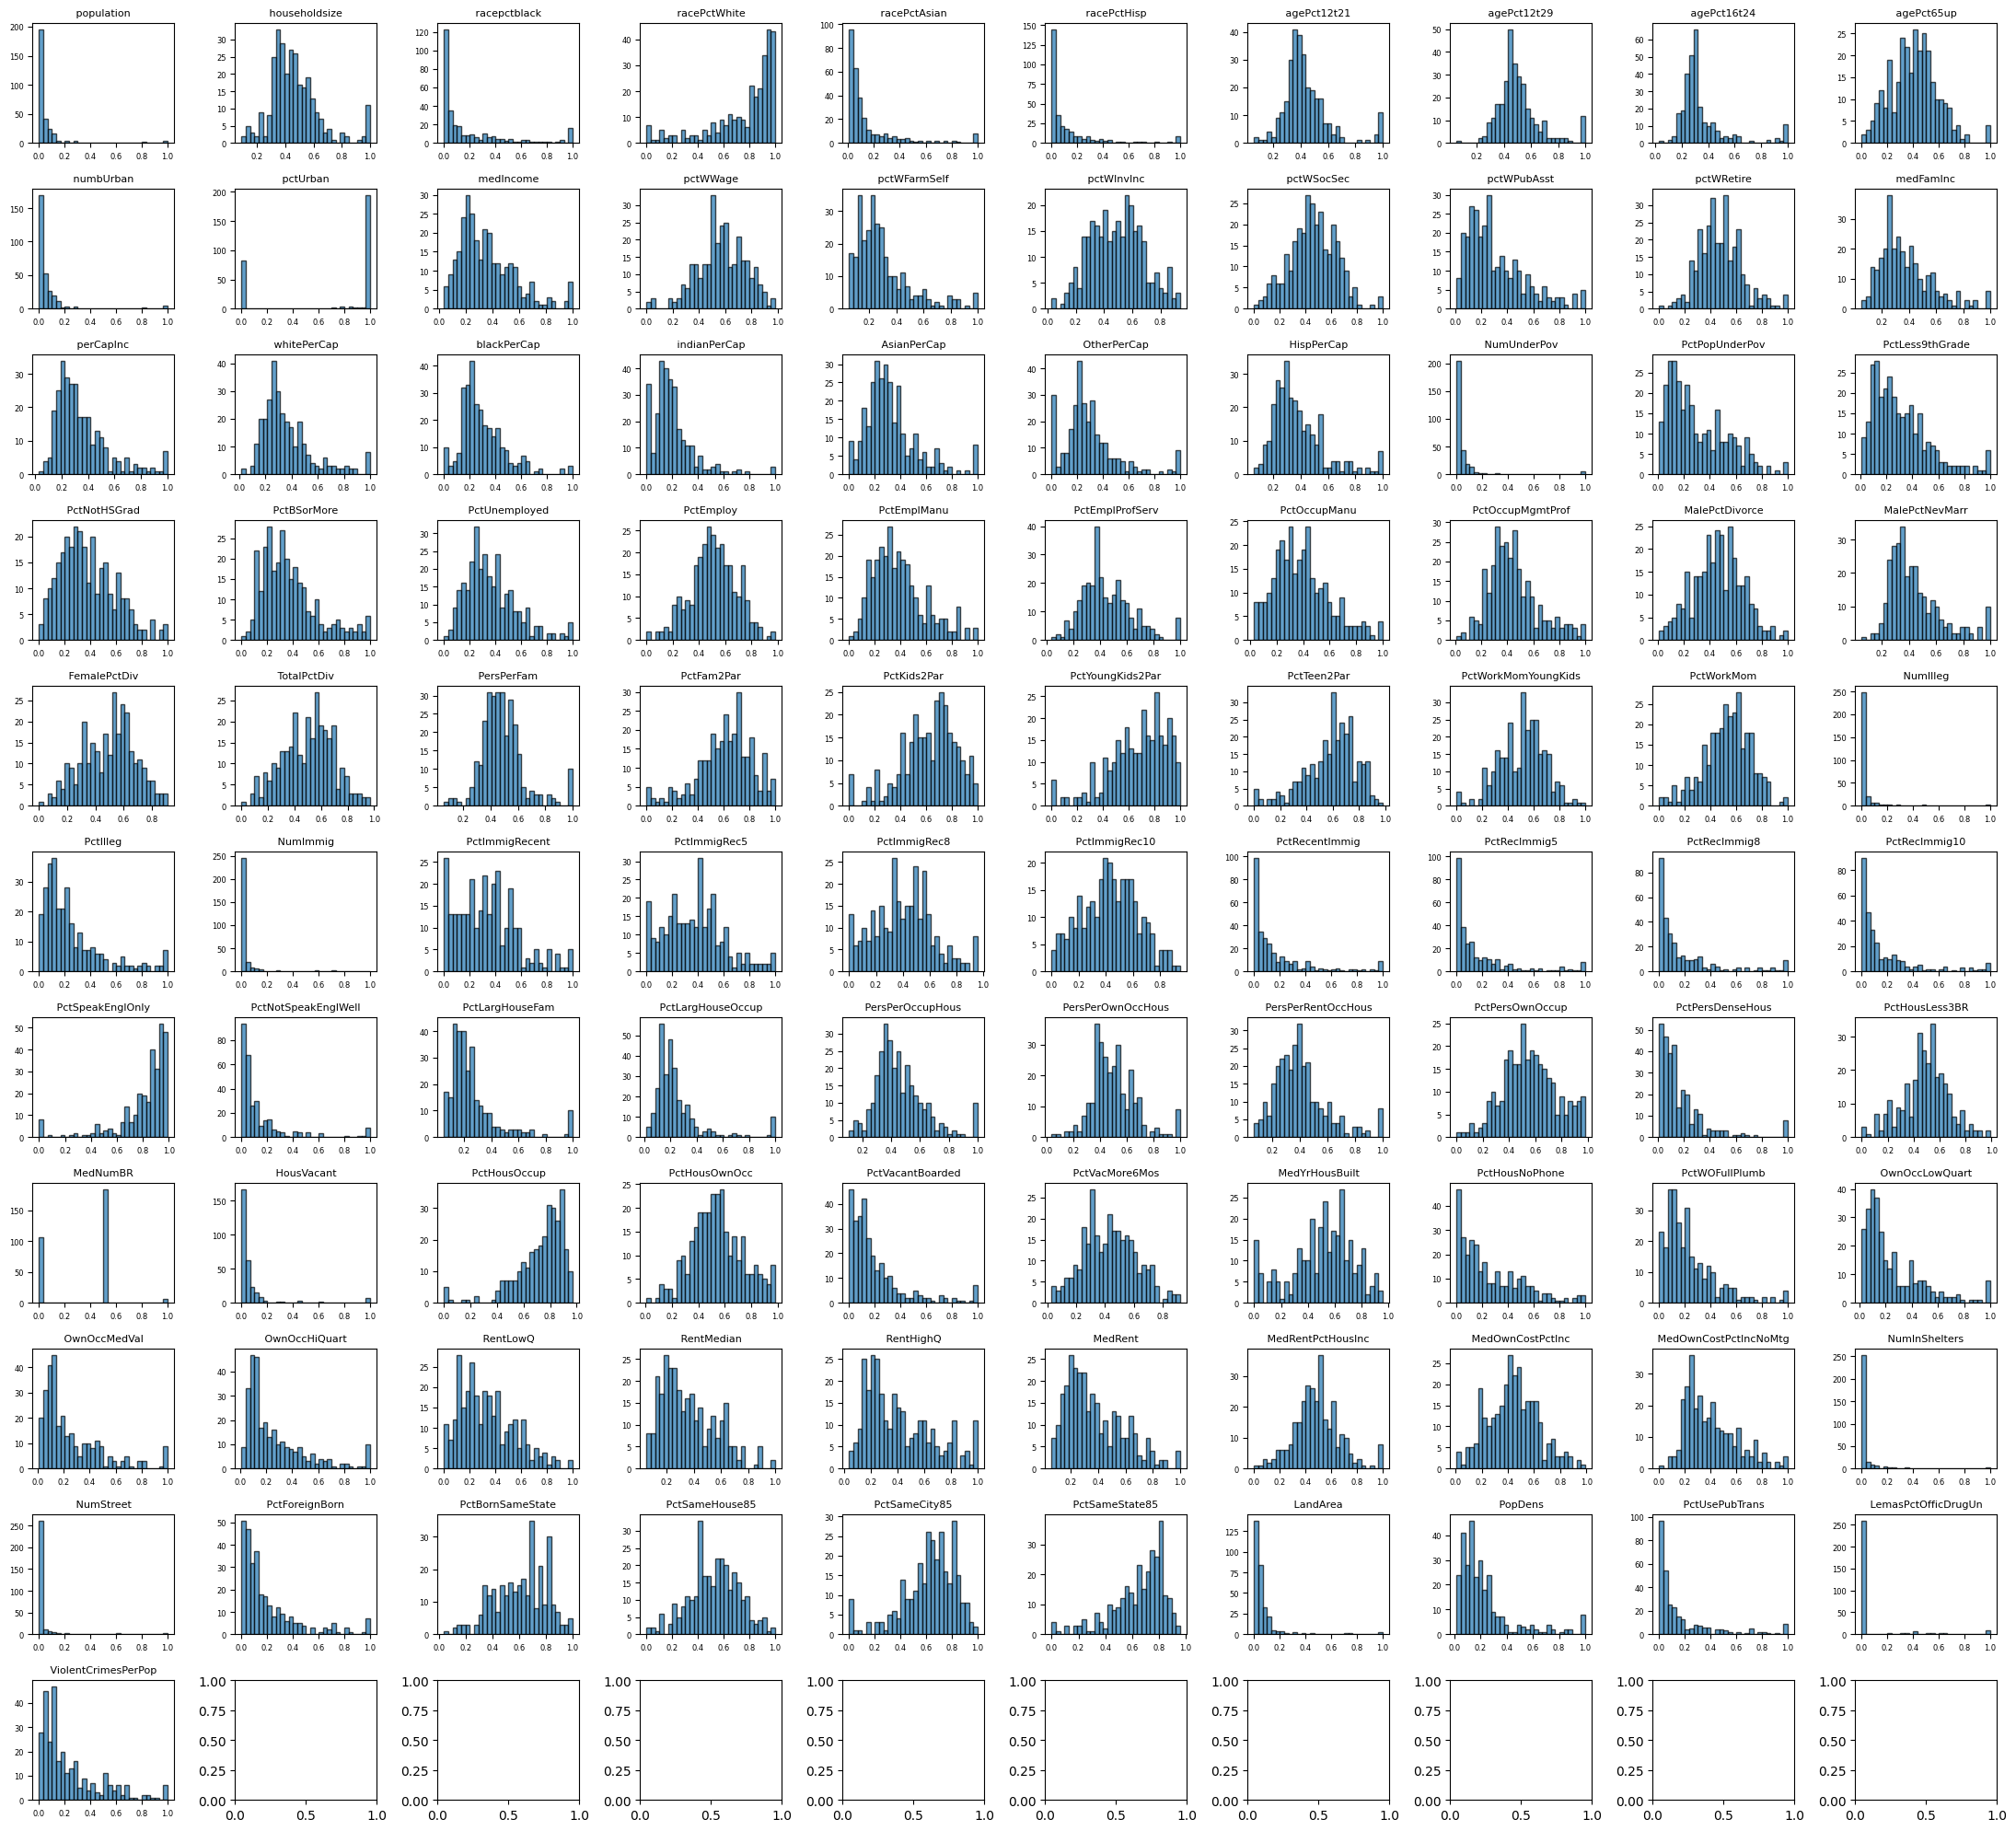

In [15]:
import matplotlib.pyplot as plt

for dataset in [train, val, test]:
    fig, axes = plt.subplots(11, 10, figsize=(22, 20))
    axes = axes.flatten()

    for idx, col in enumerate(dataset.columns):
        axes[idx].hist(dataset[col], bins=30, edgecolor='black', alpha=0.7)
        axes[idx].set_title(col, fontsize=8)
        axes[idx].tick_params(labelsize=6)

    plt.tight_layout()
    plt.show()

#### Interpretation of data distribution plots

As there is a large number of variables (101 input/output var.'s across 3 datasets) it's unreasonable to analyse each data distribution and adjust the skew accordingly, reviewing the distributions at a high level, it can be observed that the distributions remain mostly the same across train, test and val. However the distributions within the dataset vary largely. A universal approach to map data of any distribution to as close to a Gaussian distribution is optimal for this data.

## Pre-processing

The pre-processing is informed by the Exploratory Data Analysis

The only required preprocessing identified from the Exploratory Data Analysis was a universal approach to map data of any distribution to as close to a Gaussian distribution. The selected approach is to use [sklearn's PowerTransformer](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PowerTransformer.html)

### PowerTransformer

In [ ]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer()

# Fit transformer on train set
X_train_transformed = pt.fit_transform(X_train)

# Transform val and test sets
X_val_transformed = pt.transform(X_val)
X_test_transformed = pt.transform(X_test)

In [17]:
# train your Linear Regression model here. Data has already been split into predictors (X_train, X_val and X_test) and the
# desired response (y_train, y_val and y_test above).
#
# Note that you DO NOT NEED to remove any variables, or add higher order terms. JUST USE THE DATA AS IS.
#

# Once you've trained the model, evaluate it. This would include:
#  - Measuring the accuracy of the model (i.e. RMSE or similar measures)
#  - Looking at the properties of the fitted model, for example the R^2, and if all terms are contributing to the model
#  - Considering the validity of the trained model. This could include assumptions about independent predictors, and the 
#    distribution of the residuals
# Your write-up should include your findings regarding the above.

In [18]:
# train your regularised models (ridge and lasso). Here you will use the same data as you used in for the above regression model
#
# One key consideration with your regularised models is the selection of lambda (i.e. the strength of the regularisation). A suggested 
# starting point for finding your value of lambda is suggested below using numpy.logspace (see 
# https://numpy.org/doc/stable/reference/generated/numpy.logspace.html). The code below will give you 50 values starting at 10-10 and 
# finishing at 1, spread on a log scale. Just note that for plotting things that result from this, you may want to change the scale of 
# your x-axis to a log scale (see https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.xscale.html)
#
# Note that the below list of lambda is going to be fairly coarse. For the sake of speed, we suggest that you avoid evaluating a huge
# number of lambdas in one pass, but you can get a more precise estimate by refining your estimate over multiple passes (i.e. if your
# initial estimate if 0.1, you could run the search again now looking over a range of [0.01 .. 1.0] or similar). If you wish to do this,
# we suggest limiting yourself to 2-3 passes at most. You do not need to get the perfect value of lambda.
#
# remember that lambda is a keyword in python, so we're calling the array below alphas. 
#
alphas = numpy.logspace(-10, 0)

# Once you've found your ridge and lasso models, evaluate them, following the approach you've used for the linear method, and compare the
# three models.

NameError: name 'numpy' is not defined

In [ ]:
# For your write-up, you should include:
# - a discussion of any pre-processing you did and why; or why you left the data as-is
# - a discussion of how you selected the values of lambda used in your regularised models, and what those values are
# - a comparison of three models, considering both the accuracy and validity of the models, as outlined above, this means:
#   > accuracy of the model
#   > measures of fit, such as R^2
#   > testing assumptions about the independence of predictors, and the distribution of the residuals
# - A discussion of the ethical concerns that need to be considered when evaluating the models developed for this problem
# Your write-up should be supported by appropriate figures and tables. Figures and tables should have numbers and meaningful captions. 
# Note that figures and tables are not included in the page limits.
#
# SEE THE ASSIGNMENT BRIEF ON CANVAS FOR MORE DETAILS AND NOTE THAT A NOTEBOOK FILE DOES NOT CONSTITUTE A VALID SUBMISSION. 
# YOU SHOULD WRITE UP YOUR RESPONSE IN A SEPARATE DOCUMENT